# PortAventura World - 12-Month Sales (Attendance) Forecasting Model

Long-term forecasting model comparing **monthly** vs **weekly** granularity across multiple model families.

**Objective**: Forecast attendance (proxy for sales) up to 12 months ahead, selecting the best model and granularity combination.

**Models evaluated**:
- **Statistical**: Seasonal Naive, SARIMAX, ETS (Holt-Winters), Prophet, Theta
- **Machine Learning**: XGBoost, LightGBM
- **Ensemble**: Inverse-MAPE weighted average of top performers

**Evaluation**: Time-series train/test split with MAPE as primary metric.

In [37]:
# Install dependencies
!pip install -q prophet statsmodels scikit-learn xgboost lightgbm holidays pandas numpy matplotlib seaborn

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Statistical models
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.forecasting.theta import ThetaModel
from prophet import Prophet

# ML models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

# Holidays
import holidays

# Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 1. Data Loading & Exploration

Date range: 2018-06-01 to 2022-07-26
Total daily records: 1182

Attendance statistics:
count     1182.0
mean     34797.0
std      18325.0
min      -9991.0
25%      21701.0
50%      35672.0
75%      49564.0
max      80642.0
Name: attendance, dtype: float64


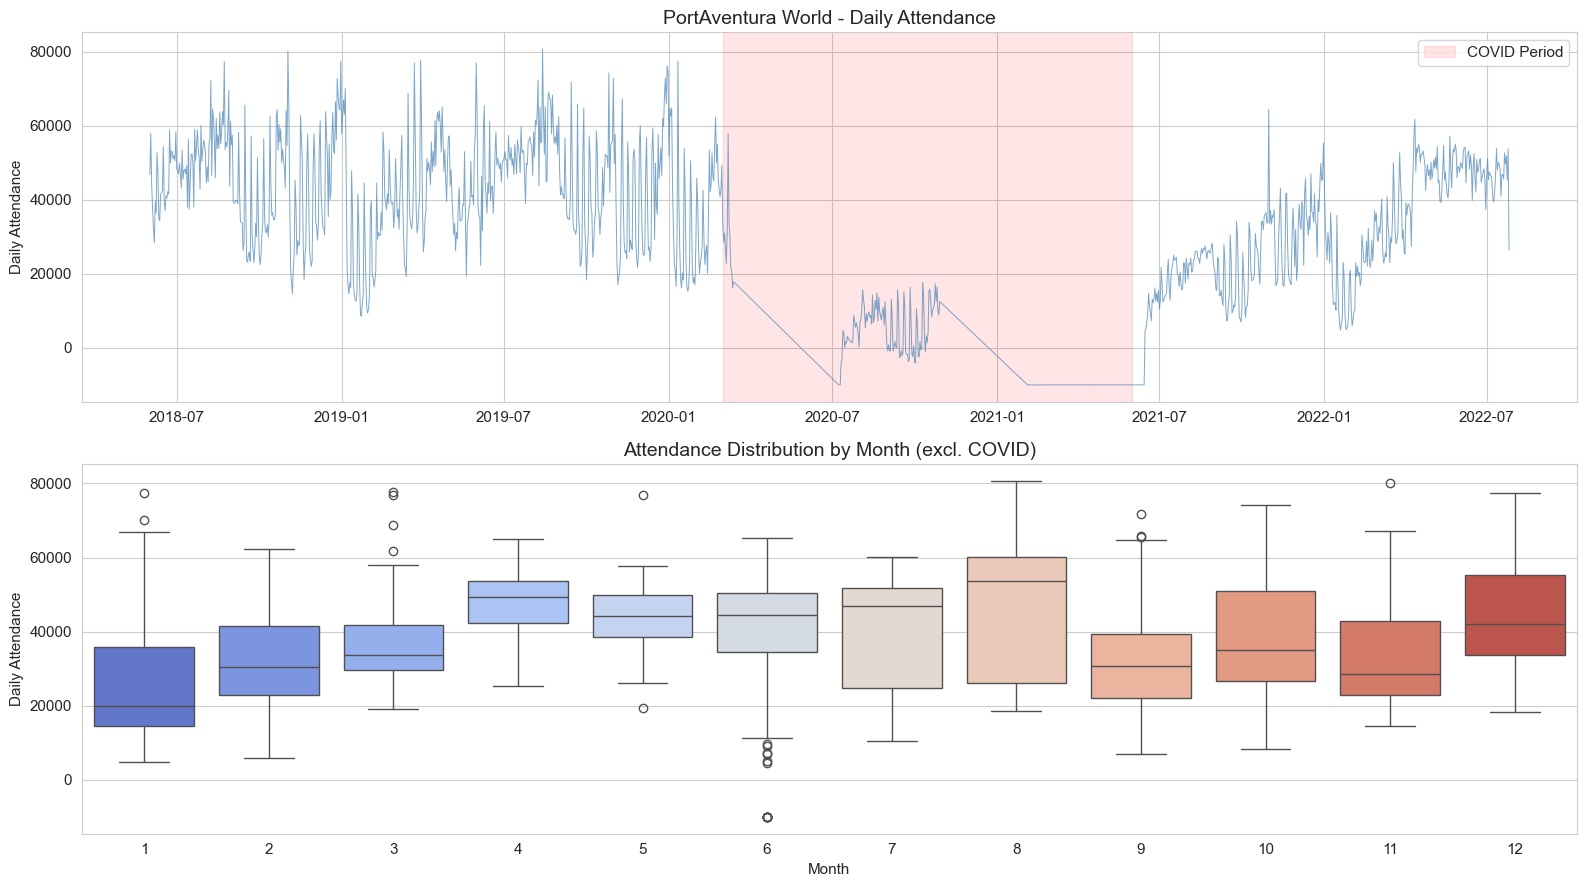

In [39]:
# Determine data directory (works from both notebooks/ and project root)
import os
if os.path.exists('final_data/attendance.csv'):
    DATA_DIR = 'final_data'
elif os.path.exists('../final_data/attendance.csv'):
    DATA_DIR = '../final_data'
else:
    raise FileNotFoundError("Cannot find final_data/ directory. Run from project root or notebooks/.")

# Load attendance data
df = pd.read_csv(f'{DATA_DIR}/attendance.csv')
df['USAGE_DATE'] = pd.to_datetime(df['USAGE_DATE'])

# Filter for PortAventura World only
pa = df[df['FACILITY_NAME'] == 'PortAventura World'].copy()
pa = pa.sort_values('USAGE_DATE').reset_index(drop=True)

print(f"Date range: {pa['USAGE_DATE'].min().date()} to {pa['USAGE_DATE'].max().date()}")
print(f"Total daily records: {len(pa)}")
print(f"\nAttendance statistics:")
print(pa['attendance'].describe().round(0))

# Daily attendance plot
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

axes[0].plot(pa['USAGE_DATE'], pa['attendance'], linewidth=0.7, alpha=0.7, color='steelblue')
axes[0].axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-06-01'),
                color='red', alpha=0.1, label='COVID Period')
axes[0].set_title('PortAventura World - Daily Attendance')
axes[0].set_ylabel('Daily Attendance')
axes[0].legend()

# Monthly boxplot to show seasonality
pa['month'] = pa['USAGE_DATE'].dt.month
monthly_box = pa[~((pa['USAGE_DATE'] >= '2020-03-01') & (pa['USAGE_DATE'] <= '2021-06-01'))]
sns.boxplot(data=monthly_box, x='month', y='attendance', ax=axes[1], palette='coolwarm')
axes[1].set_title('Attendance Distribution by Month (excl. COVID)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Daily Attendance')

plt.tight_layout()
plt.show()

## 2. Monthly Aggregation & Feature Engineering

Monthly data: 50 observations
Date range: 2018-06-01 to 2022-07-01


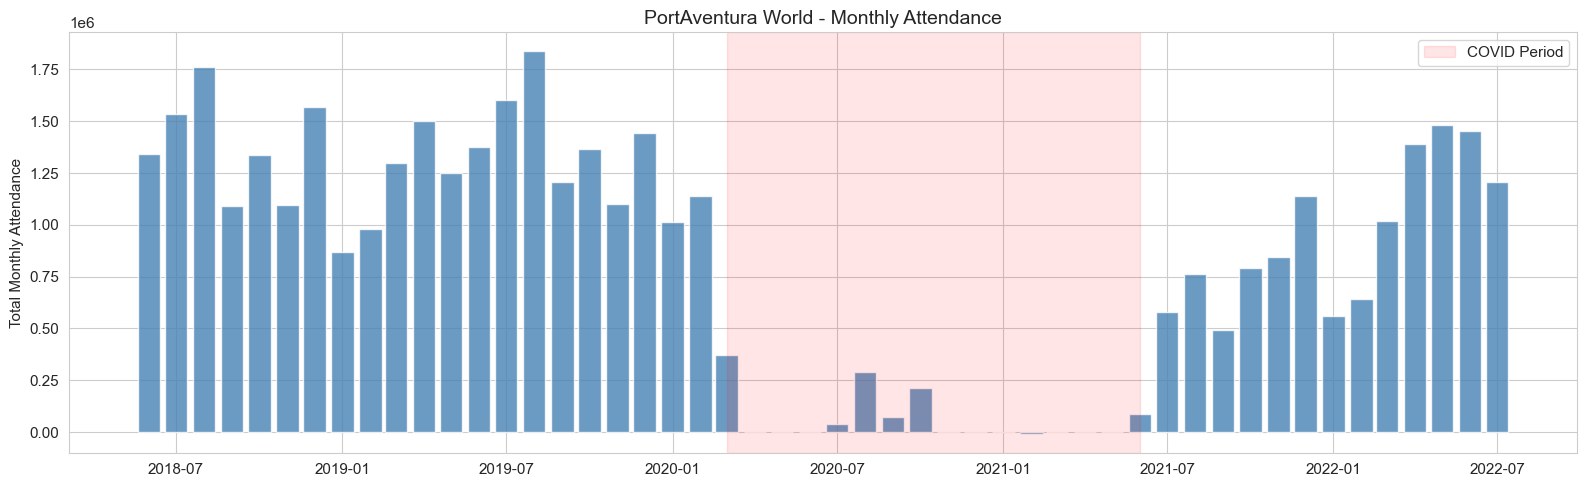

,attendance,month,quarter,is_summer,is_holiday_season,covid_dummy,recovery_dummy,n_holidays,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_mean_6,rolling_std_3
date,,,,,,,,,,,,,,,
2018-06-01,1340826,6,2,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-07-01,1533705,7,3,1,0,0,0,0,1340826.0,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-01,1759533,8,3,1,0,0,0,1,1533705.0,1340826.0,NaN,NaN,NaN,NaN,NaN
2018-09-01,1089890,9,3,1,0,0,0,1,1759533.0,1533705.0,1340826.0,NaN,1.544688e+06,NaN,209569.457887
2018-10-01,1339396,10,4,0,0,0,0,1,1089890.0,1759533.0,1533705.0,NaN,1.461043e+06,NaN,340683.574415
2018-11-01,1097089,11,4,0,0,0,0,1,1339396.0,1089890.0,1759533.0,NaN,1.396273e+06,NaN,338425.297088
2018-12-01,1568216,12,4,0,1,0,0,4,1097089.0,1339396.0,1089890.0,NaN,1.175458e+06,1.360073e+06,142019.806064
2019-01-01,867932,1,1,0,1,0,0,1,1568216.0,1097089.0,1339396.0,NaN,1.334900e+06,1.397972e+06,235595.672278
2019-02-01,978219,2,1,0,0,0,0,0,867932.0,1568216.0,1097089.0,NaN,1.177746e+06,1.287009e+06,357041.375155


In [40]:
# Monthly aggregation
pa_monthly = pa.set_index('USAGE_DATE').resample('MS')['attendance'].sum().reset_index()
pa_monthly.columns = ['date', 'attendance']
pa_monthly = pa_monthly.set_index('date')

# Ensure continuous monthly frequency (fill missing months with 0)
full_months = pd.date_range(start=pa_monthly.index.min(), end=pa_monthly.index.max(), freq='MS')
pa_monthly = pa_monthly.reindex(full_months, fill_value=0)
pa_monthly.index.name = 'date'
pa_monthly.index.freq = 'MS'

# ----- Calendar Features -----
pa_monthly['month'] = pa_monthly.index.month
pa_monthly['quarter'] = pa_monthly.index.quarter
pa_monthly['is_summer'] = pa_monthly['month'].isin([6, 7, 8, 9]).astype(int)
pa_monthly['is_holiday_season'] = pa_monthly['month'].isin([12, 1]).astype(int)

# ----- COVID & Recovery Dummies -----
pa_monthly['covid_dummy'] = (
    (pa_monthly.index >= '2020-03-01') & (pa_monthly.index <= '2021-06-01')
).astype(int)
pa_monthly['recovery_dummy'] = (pa_monthly.index >= '2021-07-01').astype(int)

# ----- Spanish Holidays (Catalonia / Tarragona) -----
es_holidays = holidays.Spain(prov='CT', years=range(2018, 2024))
holiday_dates = pd.to_datetime(list(es_holidays.keys()))
pa_monthly['n_holidays'] = [
    len(holiday_dates[(holiday_dates.year == d.year) & (holiday_dates.month == d.month)])
    for d in pa_monthly.index
]

# ----- Lag Features (for ML models) -----
pa_monthly['lag_1'] = pa_monthly['attendance'].shift(1)
pa_monthly['lag_2'] = pa_monthly['attendance'].shift(2)
pa_monthly['lag_3'] = pa_monthly['attendance'].shift(3)
pa_monthly['lag_12'] = pa_monthly['attendance'].shift(12)

# ----- Rolling Statistics -----
pa_monthly['rolling_mean_3'] = pa_monthly['attendance'].shift(1).rolling(3).mean()
pa_monthly['rolling_mean_6'] = pa_monthly['attendance'].shift(1).rolling(6).mean()
pa_monthly['rolling_std_3'] = pa_monthly['attendance'].shift(1).rolling(3).std()

print(f"Monthly data: {len(pa_monthly)} observations")
print(f"Date range: {pa_monthly.index.min().date()} to {pa_monthly.index.max().date()}")

# Visualize monthly attendance
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(pa_monthly.index, pa_monthly['attendance'], width=25, color='steelblue', alpha=0.8)
ax.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-06-01'),
           color='red', alpha=0.1, label='COVID Period')
ax.set_title('PortAventura World - Monthly Attendance')
ax.set_ylabel('Total Monthly Attendance')
ax.legend()
plt.tight_layout()
plt.show()

pa_monthly.head(15)

## 3. Weekly Aggregation & Feature Engineering

Weekly data: 218 observations
Date range: 2018-06-04 to 2022-08-01


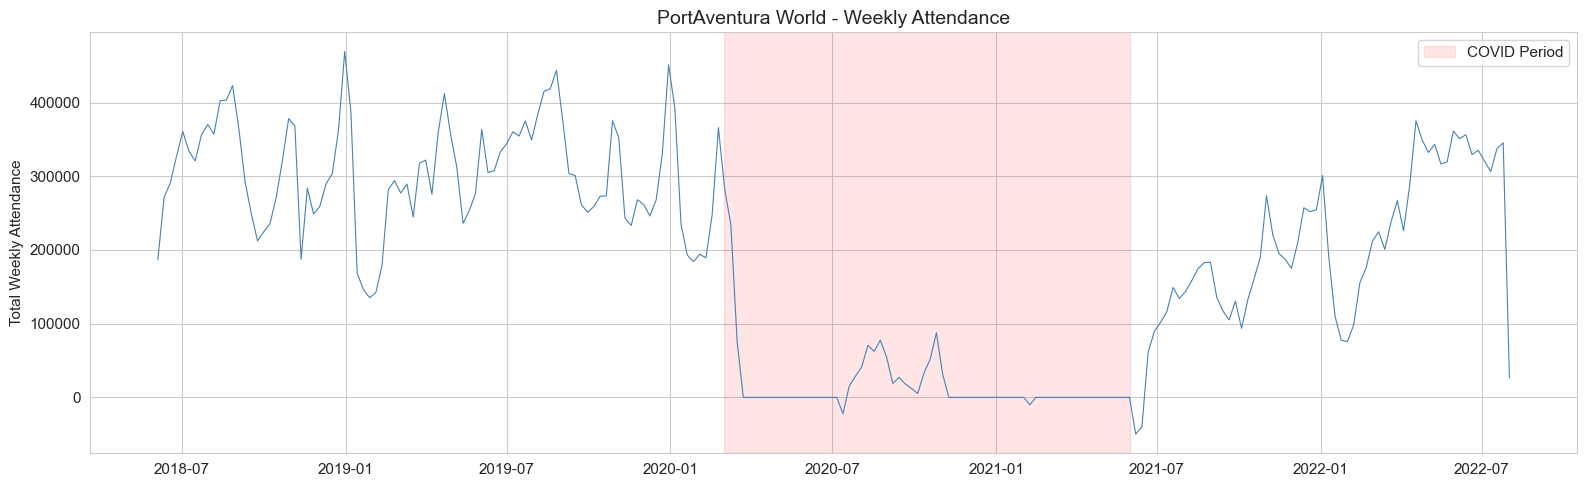

,attendance,week_of_year,month,quarter,is_summer,covid_dummy,recovery_dummy,n_holidays,lag_1,lag_2,lag_4,lag_52,rolling_mean_4,rolling_mean_12,rolling_std_4
date,,,,,,,,,,,,,,,
2018-06-04,186726,23,6,2,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-11,271405,24,6,2,1,0,0,0,186726.0,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-18,290912,25,6,2,1,0,0,0,271405.0,186726.0,NaN,NaN,NaN,NaN,NaN
2018-06-25,327127,26,6,2,1,0,0,0,290912.0,271405.0,NaN,NaN,NaN,NaN,NaN
2018-07-02,360824,27,7,3,1,0,0,0,327127.0,290912.0,186726.0,NaN,269042.50,NaN,59536.184373
2018-07-09,333891,28,7,3,1,0,0,0,360824.0,327127.0,271405.0,NaN,312567.00,NaN,39597.899431
2018-07-16,320964,29,7,3,1,0,0,0,333891.0,360824.0,290912.0,NaN,328188.50,NaN,28799.644680
2018-07-23,356263,30,7,3,1,0,0,0,320964.0,333891.0,327127.0,NaN,335701.50,NaN,17560.693542
2018-07-30,370365,31,7,3,1,0,0,0,356263.0,320964.0,360824.0,NaN,342985.50,NaN,18816.309247


In [41]:
# Weekly aggregation (Monday-start weeks)
pa_weekly = pa.set_index('USAGE_DATE').resample('W-MON')['attendance'].sum().reset_index()
pa_weekly.columns = ['date', 'attendance']
pa_weekly = pa_weekly.set_index('date')
pa_weekly.index.freq = 'W-MON'

# ----- Calendar Features -----
pa_weekly['week_of_year'] = pa_weekly.index.isocalendar().week.astype(int)
pa_weekly['month'] = pa_weekly.index.month
pa_weekly['quarter'] = pa_weekly.index.quarter
pa_weekly['is_summer'] = pa_weekly['month'].isin([6, 7, 8, 9]).astype(int)

# ----- COVID & Recovery Dummies -----
pa_weekly['covid_dummy'] = (
    (pa_weekly.index >= '2020-03-01') & (pa_weekly.index <= '2021-06-01')
).astype(int)
pa_weekly['recovery_dummy'] = (pa_weekly.index >= '2021-07-01').astype(int)

# ----- Holidays per week -----
def count_holidays_in_week(week_end_date, hol_dict):
    """Count public holidays in the 7-day period ending on week_end_date."""
    start = week_end_date - timedelta(days=6)
    return sum(1 for d in pd.date_range(start, week_end_date) if d.date() in hol_dict)

pa_weekly['n_holidays'] = [count_holidays_in_week(d, es_holidays) for d in pa_weekly.index]

# ----- Lag Features -----
pa_weekly['lag_1'] = pa_weekly['attendance'].shift(1)
pa_weekly['lag_2'] = pa_weekly['attendance'].shift(2)
pa_weekly['lag_4'] = pa_weekly['attendance'].shift(4)
pa_weekly['lag_52'] = pa_weekly['attendance'].shift(52)

# ----- Rolling Statistics -----
pa_weekly['rolling_mean_4'] = pa_weekly['attendance'].shift(1).rolling(4).mean()
pa_weekly['rolling_mean_12'] = pa_weekly['attendance'].shift(1).rolling(12).mean()
pa_weekly['rolling_std_4'] = pa_weekly['attendance'].shift(1).rolling(4).std()

print(f"Weekly data: {len(pa_weekly)} observations")
print(f"Date range: {pa_weekly.index.min().date()} to {pa_weekly.index.max().date()}")

# Visualize weekly attendance
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(pa_weekly.index, pa_weekly['attendance'], linewidth=0.8, color='steelblue')
ax.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-06-01'),
           color='red', alpha=0.1, label='COVID Period')
ax.set_title('PortAventura World - Weekly Attendance')
ax.set_ylabel('Total Weekly Attendance')
ax.legend()
plt.tight_layout()
plt.show()

pa_weekly.head(10)

## 4. Train/Test Split & Evaluation Helpers

In [42]:
# ===== TRAIN / TEST SPLIT =====

# Prediction interval width (e.g. 0.05 = +/-2.5% around point prediction)
# Change this variable to adjust the interval
INTERVAL_WIDTH = 0.05
half_interval = INTERVAL_WIDTH / 2

# Monthly: hold out last 6 months for testing
MONTHLY_TEST_SIZE = 6
monthly_train = pa_monthly.iloc[:-MONTHLY_TEST_SIZE]
monthly_test = pa_monthly.iloc[-MONTHLY_TEST_SIZE:]

# Weekly: hold out last 26 weeks (~6 months) for testing, then ignore the most recent point
WEEKLY_TEST_SIZE = 26
weekly_train = pa_weekly.iloc[:-WEEKLY_TEST_SIZE]
weekly_test = pa_weekly.iloc[-WEEKLY_TEST_SIZE:-1]  # ignore latest weekly datapoint

print("=" * 60)
print("MONTHLY SPLIT")
print(f"  Train: {len(monthly_train)} months  ({monthly_train.index.min().date()} to {monthly_train.index.max().date()})")
print(f"  Test:  {len(monthly_test)} months  ({monthly_test.index.min().date()} to {monthly_test.index.max().date()})")
print(f"\nWEEKLY SPLIT")
print(f"  Train: {len(weekly_train)} weeks   ({weekly_train.index.min().date()} to {weekly_train.index.max().date()})")
print(f"  Test:  {len(weekly_test)} weeks   ({weekly_test.index.min().date()} to {weekly_test.index.max().date()})")
print("=" * 60)

# ===== EVALUATION HELPERS =====

def evaluate(y_true, y_pred, model_name):
    """Evaluate forecast and return metrics dict. Filters out zero-attendance periods for MAPE."""
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    # Ensure same length
    min_len = min(len(y_true), len(y_pred))
    y_true = y_true[:min_len]
    y_pred = y_pred[:min_len]
    
    # Filter out zero actuals for MAPE (park closed)
    mask = y_true > 0
    if mask.sum() == 0:
        return {'Model': model_name, 'RMSE': np.nan, 'MAE': np.nan, 'MAPE': np.nan, 'R2': np.nan, 'Coverage': np.nan, 'Within': '0/0'}
    
    y_t, y_p = y_true[mask], y_pred[mask]
    
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mae = mean_absolute_error(y_t, y_p)
    mape = mean_absolute_percentage_error(y_t, y_p)
    r2 = r2_score(y_t, y_p)
    
    # Interval coverage: check if actual falls within [pred*(1-half), pred*(1+half)]
    lower_b = y_p * (1 - half_interval)
    upper_b = y_p * (1 + half_interval)
    within_count = int(((y_t >= lower_b) & (y_t <= upper_b)).sum())
    coverage = within_count / len(y_t)
    
    return {'Model': model_name, 'RMSE': round(rmse, 0), 'MAE': round(mae, 0), 'MAPE': round(mape, 4), 'R2': round(r2, 4), 'Coverage': round(coverage, 4), 'Within': f'{within_count}/{len(y_t)}'}


def plot_forecast(train_data, test_data, predictions_dict, title):
    """Plot train, test, and multiple model predictions."""
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(train_data.index, train_data['attendance'], label='Train', color='gray', linewidth=0.8)
    ax.plot(test_data.index, test_data['attendance'], label='Actual (Test)', color='black',
            linewidth=2.5, linestyle='--', marker='o', markersize=5)
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(predictions_dict)))
    for (name, preds), color in zip(predictions_dict.items(), colors):
        preds_arr = np.array(preds).flatten()[:len(test_data)]
        ax.plot(test_data.index[:len(preds_arr)], preds_arr, label=name, alpha=0.85, linewidth=1.8, color=color)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Attendance')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

MONTHLY SPLIT
  Train: 44 months  (2018-06-01 to 2022-01-01)
  Test:  6 months  (2022-02-01 to 2022-07-01)

WEEKLY SPLIT
  Train: 192 weeks   (2018-06-04 to 2022-01-31)
  Test:  25 weeks   (2022-02-07 to 2022-07-25)


## 5. Monthly Models

### 5.1 Statistical Models (Seasonal Naive, SARIMAX, ETS, Prophet, Theta)

In [43]:
# ===== MONTHLY STATISTICAL MODELS =====
monthly_preds = {}
monthly_intervals = {}  # Store (lower, upper) 95% CI for each model
monthly_results = []

# ------------------------------------------------------------------
# 1. Seasonal Naive (same month last year)
# ------------------------------------------------------------------
naive_pred = pa_monthly['attendance'].shift(12).iloc[-MONTHLY_TEST_SIZE:]
monthly_preds['Seasonal Naive'] = naive_pred.values
# Interval: use historical year-over-year residual std
naive_residuals = (pa_monthly['attendance'] - pa_monthly['attendance'].shift(12)).dropna()
naive_std = naive_residuals.std()
monthly_intervals['Seasonal Naive'] = (
    np.maximum(naive_pred.values - 1.96 * naive_std, 0),
    naive_pred.values + 1.96 * naive_std
)
r = evaluate(monthly_test['attendance'], naive_pred.values, 'Seasonal Naive')
monthly_results.append(r)
print(f"1. Seasonal Naive  -> MAPE: {r['MAPE']:.2%}")

# ------------------------------------------------------------------
# 2. SARIMAX with COVID exogenous
# ------------------------------------------------------------------
try:
    sarima = SARIMAX(
        monthly_train['attendance'],
        exog=monthly_train[['covid_dummy']],
        order=(1, 1, 1),
        seasonal_order=(1, 1, 0, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_fit = sarima.fit(disp=False)
    sarima_fc = sarima_fit.get_forecast(steps=MONTHLY_TEST_SIZE,
                                         exog=monthly_test[['covid_dummy']])
    monthly_preds['SARIMAX'] = sarima_fc.predicted_mean.values
    ci = sarima_fc.conf_int()
    monthly_intervals['SARIMAX'] = (np.maximum(ci.iloc[:, 0].values, 0), ci.iloc[:, 1].values)
    r = evaluate(monthly_test['attendance'], sarima_fc.predicted_mean.values, 'SARIMAX')
    monthly_results.append(r)
    print(f"2. SARIMAX         -> MAPE: {r['MAPE']:.2%}  (AIC: {sarima_fit.aic:.0f})")
except Exception as e:
    print(f"2. SARIMAX failed: {e}")

# ------------------------------------------------------------------
# 3. ETS (Holt-Winters) - try additive and multiplicative seasonal
# ------------------------------------------------------------------
for stype in ['add', 'mul']:
    try:
        ets = ExponentialSmoothing(
            monthly_train['attendance'],
            trend='add',
            seasonal=stype,
            seasonal_periods=12,
            initialization_method='estimated'
        ).fit(optimized=True)
        ets_pred = ets.forecast(MONTHLY_TEST_SIZE)
        name = f'ETS ({stype})'
        monthly_preds[name] = ets_pred.values
        resid_std = ets.resid.std()
        monthly_intervals[name] = (
            np.maximum(ets_pred.values - 1.96 * resid_std, 0),
            ets_pred.values + 1.96 * resid_std
        )
        r = evaluate(monthly_test['attendance'], ets_pred.values, name)
        monthly_results.append(r)
        print(f"3. {name:16s} -> MAPE: {r['MAPE']:.2%}")
    except Exception as e:
        print(f"3. ETS ({stype}) failed: {e}")

# ------------------------------------------------------------------
# 4. Prophet with COVID regressor
# ------------------------------------------------------------------
prophet_train_df = monthly_train.reset_index().rename(columns={'date': 'ds', 'attendance': 'y'})
prophet_train_df['covid_dummy'] = monthly_train['covid_dummy'].values

m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
            changepoint_prior_scale=0.05)
m.add_regressor('covid_dummy')
m.fit(prophet_train_df)

future = m.make_future_dataframe(periods=MONTHLY_TEST_SIZE, freq='MS')
future['covid_dummy'] = 0
future.loc[future['ds'].isin(monthly_train.reset_index()['date']), 'covid_dummy'] = \
    monthly_train['covid_dummy'].values
forecast_prophet = m.predict(future)

prophet_pred = forecast_prophet.iloc[-MONTHLY_TEST_SIZE:]['yhat'].values
prophet_pred = np.maximum(prophet_pred, 0)  # attendance cannot be negative
monthly_preds['Prophet'] = prophet_pred
monthly_intervals['Prophet'] = (
    np.maximum(forecast_prophet.iloc[-MONTHLY_TEST_SIZE:]['yhat_lower'].values, 0),
    forecast_prophet.iloc[-MONTHLY_TEST_SIZE:]['yhat_upper'].values
)
r = evaluate(monthly_test['attendance'], prophet_pred, 'Prophet')
monthly_results.append(r)
print(f"4. Prophet         -> MAPE: {r['MAPE']:.2%}")

# ------------------------------------------------------------------
# 5. Theta Method
# ------------------------------------------------------------------
try:
    theta = ThetaModel(monthly_train['attendance'], period=12)
    theta_fit = theta.fit()
    theta_pred = theta_fit.forecast(MONTHLY_TEST_SIZE)
    monthly_preds['Theta'] = theta_pred.values
    theta_ci = theta_fit.prediction_intervals(MONTHLY_TEST_SIZE)
    monthly_intervals['Theta'] = (np.maximum(theta_ci.iloc[:, 0].values, 0), theta_ci.iloc[:, 1].values)
    r = evaluate(monthly_test['attendance'], theta_pred.values, 'Theta')
    monthly_results.append(r)
    print(f"5. Theta           -> MAPE: {r['MAPE']:.2%}")
except Exception as e:
    print(f"5. Theta failed: {e}")

print("\n--- Monthly Statistical Models Complete ---")

1. Seasonal Naive  -> MAPE: 91.25%
2. SARIMAX         -> MAPE: 47.28%  (AIC: 504)


16:40:21 - cmdstanpy - INFO - Chain [1] start processing


3. ETS (add)        -> MAPE: 56.80%
3. ETS (mul) failed: endog must be strictly positive when usingmultiplicative trend or seasonal components.


16:40:21 - cmdstanpy - INFO - Chain [1] done processing


4. Prophet         -> MAPE: 38.00%
5. Theta           -> MAPE: 43.12%

--- Monthly Statistical Models Complete ---


### 5.2 Monthly ML Models (XGBoost, LightGBM)

ML models use lag features and calendar variables. Note: for the test evaluation, actual historical values are used as lag inputs (one-step-ahead paradigm). Statistical models above perform true multi-step-ahead forecasting.

ML Monthly - Train: 32 samples, Test: 6 samples
Features: 14
6. XGBoost         -> MAPE: 25.81%
7. LightGBM        -> MAPE: 31.23%


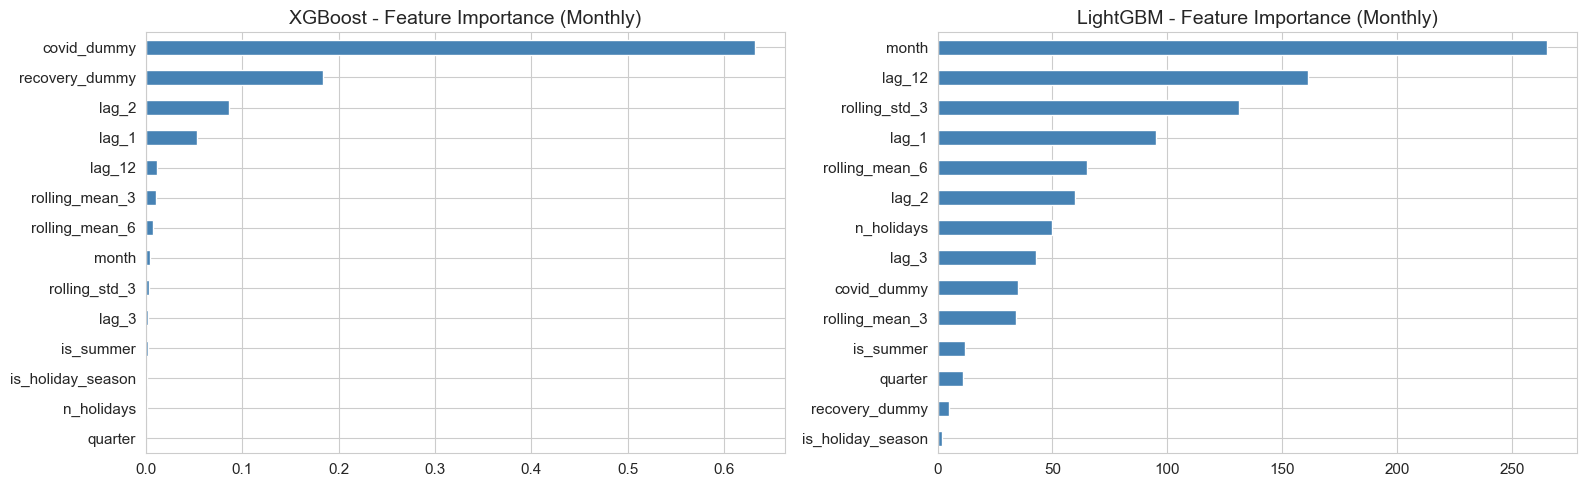

In [44]:
# ===== MONTHLY ML MODELS =====

ml_features_monthly = ['month', 'quarter', 'is_summer', 'is_holiday_season',
                        'covid_dummy', 'recovery_dummy', 'n_holidays',
                        'lag_1', 'lag_2', 'lag_3', 'lag_12',
                        'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3']

# Drop rows with NaN in lag/rolling features (first ~12 months)
ml_monthly = pa_monthly.dropna(subset=ml_features_monthly).copy()
test_start = monthly_test.index[0]

ml_train_m = ml_monthly[ml_monthly.index < test_start]
ml_test_m = ml_monthly[ml_monthly.index >= test_start]

X_train_m = ml_train_m[ml_features_monthly]
y_train_m = ml_train_m['attendance']
X_test_m = ml_test_m[ml_features_monthly]
y_test_m = ml_test_m['attendance']

print(f"ML Monthly - Train: {len(X_train_m)} samples, Test: {len(X_test_m)} samples")
print(f"Features: {len(ml_features_monthly)}")

# ------------------------------------------------------------------
# 6. XGBoost
# ------------------------------------------------------------------
xgb_m = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.08,
                      min_child_weight=3, subsample=0.8, random_state=42, verbosity=0)
xgb_m.fit(X_train_m, y_train_m)
xgb_pred_m = np.maximum(xgb_m.predict(X_test_m), 0)
monthly_preds['XGBoost'] = xgb_pred_m
xgb_resid_std = (y_train_m - xgb_m.predict(X_train_m)).std()
monthly_intervals['XGBoost'] = (
    np.maximum(xgb_pred_m - 1.96 * xgb_resid_std, 0),
    xgb_pred_m + 1.96 * xgb_resid_std
)
r = evaluate(y_test_m, xgb_pred_m, 'XGBoost')
monthly_results.append(r)
print(f"6. XGBoost         -> MAPE: {r['MAPE']:.2%}")

# ------------------------------------------------------------------
# 7. LightGBM
# ------------------------------------------------------------------
lgb_m = LGBMRegressor(n_estimators=200, max_depth=3, learning_rate=0.08,
                       min_child_samples=3, subsample=0.8, random_state=42, verbose=-1)
lgb_m.fit(X_train_m, y_train_m)
lgb_pred_m = np.maximum(lgb_m.predict(X_test_m), 0)
monthly_preds['LightGBM'] = lgb_pred_m
lgb_resid_std = (y_train_m - lgb_m.predict(X_train_m)).std()
monthly_intervals['LightGBM'] = (
    np.maximum(lgb_pred_m - 1.96 * lgb_resid_std, 0),
    lgb_pred_m + 1.96 * lgb_resid_std
)
r = evaluate(y_test_m, lgb_pred_m, 'LightGBM')
monthly_results.append(r)
print(f"7. LightGBM        -> MAPE: {r['MAPE']:.2%}")

# Feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, model, name in zip(axes, [xgb_m, lgb_m], ['XGBoost', 'LightGBM']):
    importance = pd.Series(model.feature_importances_, index=ml_features_monthly).sort_values()
    importance.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} - Feature Importance (Monthly)')
plt.tight_layout()
plt.show()

### 5.3 Monthly Ensemble & Results Summary

Top 3 models for ensemble: ['XGBoost', 'LightGBM', 'Prophet']
Ensemble weights:
  XGBoost: 0.399
  LightGBM: 0.330
  Prophet: 0.271

8. Ensemble (Top3) -> MAPE: 30.34%

MONTHLY MODEL RESULTS (sorted by MAPE)


,Model,RMSE,MAE,MAPE,R2,Coverage,Within
0,XGBoost,408030.0,335090.0,0.2581,-0.8993,0.1667,1/6
1,Ensemble (Top 3),472557.0,403175.0,0.3034,-1.5475,0.1667,1/6
2,LightGBM,490709.0,409322.0,0.3123,-1.7470,0.0000,0/6
3,Prophet,587274.0,509219.0,0.3800,-2.9345,0.0000,0/6
4,Theta,640328.0,570235.0,0.4312,-3.6775,0.0000,0/6
5,SARIMAX,710454.0,628809.0,0.4728,-4.7581,0.1667,1/6
6,ETS (add),858765.0,757341.0,0.5680,-7.4132,0.1667,1/6
7,Seasonal Naive,1144180.0,1089562.0,0.9125,-13.9348,0.0000,0/6


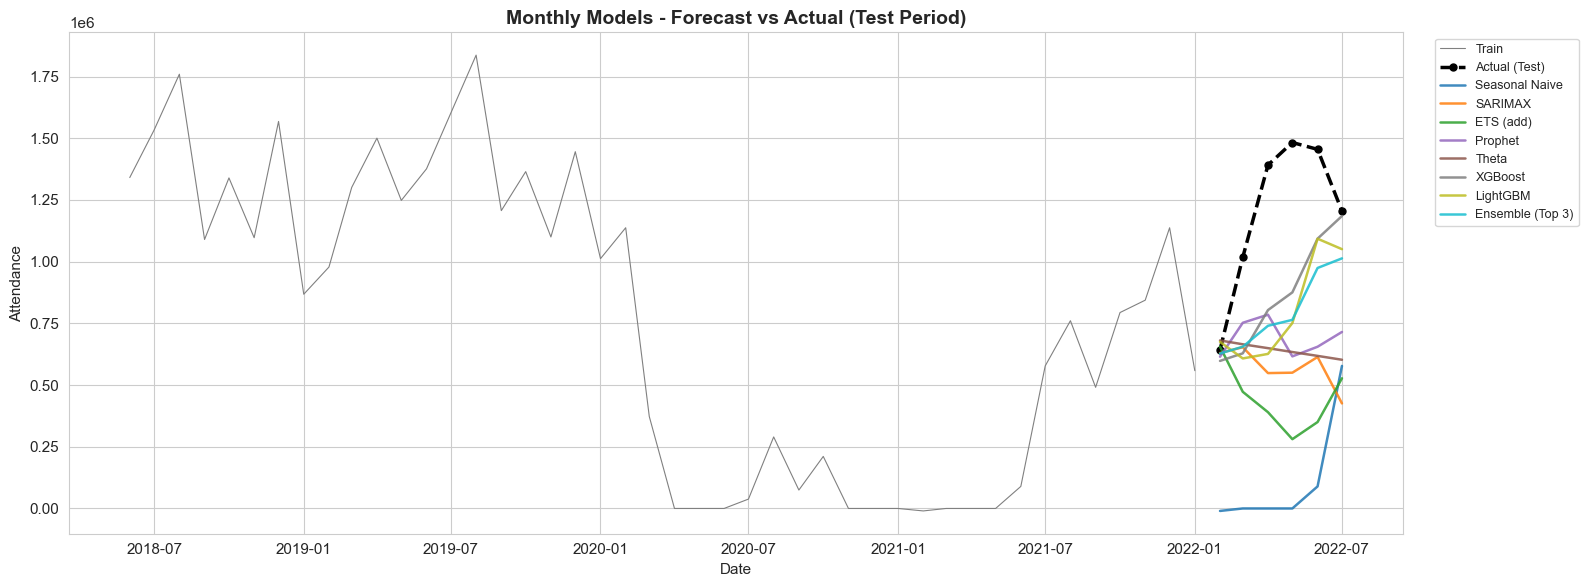

In [45]:
# ===== MONTHLY ENSEMBLE (Inverse-MAPE Weighted Top 3) =====

# Sort current results by MAPE
monthly_results_df = pd.DataFrame(monthly_results).sort_values('MAPE').reset_index(drop=True)

# Get top 3 models that have full-length predictions aligned to test set
top3_names = []
for _, row in monthly_results_df.iterrows():
    name = row['Model']
    if name in monthly_preds and len(monthly_preds[name]) == MONTHLY_TEST_SIZE:
        top3_names.append(name)
    if len(top3_names) == 3:
        break

print(f"Top 3 models for ensemble: {top3_names}")

# Compute inverse-MAPE weights
weights = {}
for name in top3_names:
    mape = monthly_results_df[monthly_results_df['Model'] == name]['MAPE'].values[0]
    weights[name] = 1.0 / (mape + 1e-10)
total_w = sum(weights.values())
weights = {k: v / total_w for k, v in weights.items()}

print("Ensemble weights:")
for name, w in weights.items():
    print(f"  {name}: {w:.3f}")

# Weighted ensemble prediction
ensemble_pred = np.zeros(MONTHLY_TEST_SIZE)
for name, w in weights.items():
    ensemble_pred += w * np.array(monthly_preds[name])[:MONTHLY_TEST_SIZE]

monthly_preds['Ensemble (Top 3)'] = ensemble_pred
# Ensemble interval: weighted average of component intervals
ens_lower = np.zeros(MONTHLY_TEST_SIZE)
ens_upper = np.zeros(MONTHLY_TEST_SIZE)
for name, w in weights.items():
    if name in monthly_intervals:
        ens_lower += w * np.array(monthly_intervals[name][0])[:MONTHLY_TEST_SIZE]
        ens_upper += w * np.array(monthly_intervals[name][1])[:MONTHLY_TEST_SIZE]
monthly_intervals['Ensemble (Top 3)'] = (np.maximum(ens_lower, 0), ens_upper)
r = evaluate(monthly_test['attendance'], ensemble_pred, 'Ensemble (Top 3)')
monthly_results.append(r)
print(f"\n8. Ensemble (Top3) -> MAPE: {r['MAPE']:.2%}")

# ===== MONTHLY RESULTS SUMMARY =====
monthly_results_df = pd.DataFrame(monthly_results).sort_values('MAPE').reset_index(drop=True)
print("\n" + "=" * 60)
print("MONTHLY MODEL RESULTS (sorted by MAPE)")
print("=" * 60)
display(monthly_results_df)

# Visualization
plot_forecast(monthly_train, monthly_test, monthly_preds,
              'Monthly Models - Forecast vs Actual (Test Period)')

## 6. Weekly Models

### 6.1 Statistical Models (Seasonal Naive, SARIMAX, ETS, Prophet, Theta)

In [46]:
# ===== WEEKLY STATISTICAL MODELS =====
weekly_preds = {}
weekly_intervals = {}  # Store (lower, upper) 95% CI for each model
weekly_results = []

# ------------------------------------------------------------------
# 1. Seasonal Naive (same week last year)
# ------------------------------------------------------------------
naive_pred_w = pa_weekly['attendance'].shift(52).iloc[-WEEKLY_TEST_SIZE:]
weekly_preds['Seasonal Naive'] = naive_pred_w.values
naive_resid_w = (pa_weekly['attendance'] - pa_weekly['attendance'].shift(52)).dropna()
naive_std_w = naive_resid_w.std()
weekly_intervals['Seasonal Naive'] = (
    np.maximum(naive_pred_w.values - 1.96 * naive_std_w, 0),
    naive_pred_w.values + 1.96 * naive_std_w
)
r = evaluate(weekly_test['attendance'], naive_pred_w.values, 'Seasonal Naive')
weekly_results.append(r)
print(f"1. Seasonal Naive  -> MAPE: {r['MAPE']:.2%}")

# ------------------------------------------------------------------
# 2. SARIMAX (weekly, period=52)
# ------------------------------------------------------------------
try:
    # Use a simpler specification for weekly data (period=52 is computationally heavy)
    sarima_w = SARIMAX(
        weekly_train['attendance'],
        exog=weekly_train[['covid_dummy']],
        order=(1, 0, 1),
        seasonal_order=(0, 1, 1, 52),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_w_fit = sarima_w.fit(disp=False, maxiter=200)
    sarima_w_fc = sarima_w_fit.get_forecast(steps=WEEKLY_TEST_SIZE,
                                              exog=weekly_test[['covid_dummy']])
    weekly_preds['SARIMAX'] = sarima_w_fc.predicted_mean.values
    ci_w = sarima_w_fc.conf_int()
    weekly_intervals['SARIMAX'] = (np.maximum(ci_w.iloc[:, 0].values, 0), ci_w.iloc[:, 1].values)
    r = evaluate(weekly_test['attendance'], sarima_w_fc.predicted_mean.values, 'SARIMAX')
    weekly_results.append(r)
    print(f"2. SARIMAX         -> MAPE: {r['MAPE']:.2%}")
except Exception as e:
    print(f"2. SARIMAX failed: {e}")

# ------------------------------------------------------------------
# 3. ETS (Holt-Winters, period=52)
# ------------------------------------------------------------------
for stype in ['add', 'mul']:
    try:
        ets_w = ExponentialSmoothing(
            weekly_train['attendance'],
            trend='add',
            seasonal=stype,
            seasonal_periods=52,
            initialization_method='estimated'
        ).fit(optimized=True)
        ets_pred_w = ets_w.forecast(WEEKLY_TEST_SIZE)
        name = f'ETS ({stype})'
        weekly_preds[name] = ets_pred_w.values
        resid_std_w = ets_w.resid.std()
        weekly_intervals[name] = (
            np.maximum(ets_pred_w.values - 1.96 * resid_std_w, 0),
            ets_pred_w.values + 1.96 * resid_std_w
        )
        r = evaluate(weekly_test['attendance'], ets_pred_w.values, name)
        weekly_results.append(r)
        print(f"3. {name:16s} -> MAPE: {r['MAPE']:.2%}")
    except Exception as e:
        print(f"3. ETS ({stype}) failed: {e}")

# ------------------------------------------------------------------
# 4. Prophet (weekly)
# ------------------------------------------------------------------
prophet_train_w = weekly_train.reset_index().rename(columns={'date': 'ds', 'attendance': 'y'})
prophet_train_w['covid_dummy'] = weekly_train['covid_dummy'].values

m_w = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
              changepoint_prior_scale=0.05)
m_w.add_regressor('covid_dummy')
m_w.fit(prophet_train_w)

future_w = m_w.make_future_dataframe(periods=WEEKLY_TEST_SIZE, freq='W-MON')
future_w['covid_dummy'] = 0
future_w.loc[future_w['ds'].isin(weekly_train.reset_index()['date']), 'covid_dummy'] = \
    weekly_train['covid_dummy'].values
forecast_w = m_w.predict(future_w)

prophet_pred_w = forecast_w.iloc[-WEEKLY_TEST_SIZE:]['yhat'].values
prophet_pred_w = np.maximum(prophet_pred_w, 0)
weekly_preds['Prophet'] = prophet_pred_w
weekly_intervals['Prophet'] = (
    np.maximum(forecast_w.iloc[-WEEKLY_TEST_SIZE:]['yhat_lower'].values, 0),
    forecast_w.iloc[-WEEKLY_TEST_SIZE:]['yhat_upper'].values
)
r = evaluate(weekly_test['attendance'], prophet_pred_w, 'Prophet')
weekly_results.append(r)
print(f"4. Prophet         -> MAPE: {r['MAPE']:.2%}")

# ------------------------------------------------------------------
# 5. Theta (weekly, period=52)
# ------------------------------------------------------------------
try:
    theta_w = ThetaModel(weekly_train['attendance'], period=52)
    theta_w_fit = theta_w.fit()
    theta_pred_w = theta_w_fit.forecast(WEEKLY_TEST_SIZE)
    weekly_preds['Theta'] = theta_pred_w.values
    theta_ci_w = theta_w_fit.prediction_intervals(WEEKLY_TEST_SIZE)
    weekly_intervals['Theta'] = (np.maximum(theta_ci_w.iloc[:, 0].values, 0), theta_ci_w.iloc[:, 1].values)
    r = evaluate(weekly_test['attendance'], theta_pred_w.values, 'Theta')
    weekly_results.append(r)
    print(f"5. Theta           -> MAPE: {r['MAPE']:.2%}")
except Exception as e:
    print(f"5. Theta failed: {e}")

print("\n--- Weekly Statistical Models Complete ---")

1. Seasonal Naive  -> MAPE: 93.49%
2. SARIMAX failed: Provided exogenous values are not of the appropriate shape. Required (26, 1), got (25, 1).
3. ETS (add)        -> MAPE: 54.49%
3. ETS (mul) failed: endog must be strictly positive when usingmultiplicative trend or seasonal components.


16:40:34 - cmdstanpy - INFO - Chain [1] start processing
16:40:34 - cmdstanpy - INFO - Chain [1] done processing


4. Prophet         -> MAPE: 53.14%
5. Theta           -> MAPE: 74.12%

--- Weekly Statistical Models Complete ---


### 6.2 Weekly ML Models (XGBoost, LightGBM)

ML Weekly - Train: 140 samples, Test: 26 samples
6. XGBoost         -> MAPE: 59.23%
7. LightGBM        -> MAPE: 62.70%


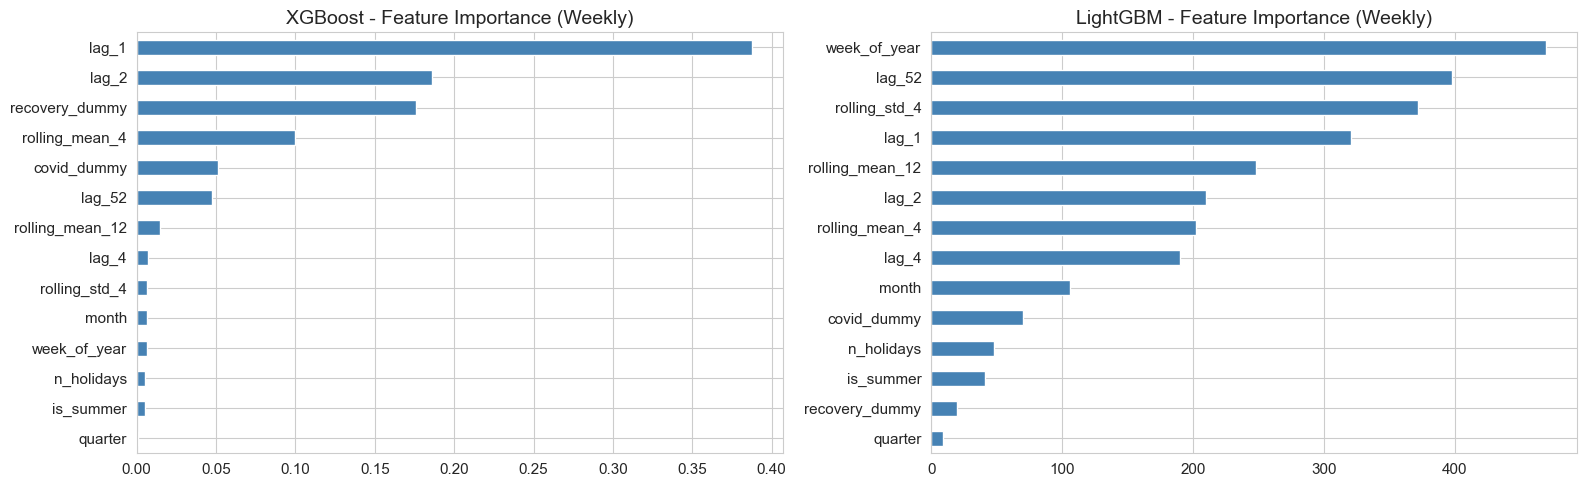

In [47]:
# ===== WEEKLY ML MODELS =====

ml_features_weekly = ['week_of_year', 'month', 'quarter', 'is_summer',
                       'covid_dummy', 'recovery_dummy', 'n_holidays',
                       'lag_1', 'lag_2', 'lag_4', 'lag_52',
                       'rolling_mean_4', 'rolling_mean_12', 'rolling_std_4']

# Drop NaN rows from lags (first ~52 weeks)
ml_weekly = pa_weekly.dropna(subset=ml_features_weekly).copy()
test_start_w = weekly_test.index[0]

ml_train_w = ml_weekly[ml_weekly.index < test_start_w]
ml_test_w = ml_weekly[ml_weekly.index >= test_start_w]

X_train_w = ml_train_w[ml_features_weekly]
y_train_w = ml_train_w['attendance']
X_test_w = ml_test_w[ml_features_weekly]
y_test_w = ml_test_w['attendance']

print(f"ML Weekly - Train: {len(X_train_w)} samples, Test: {len(X_test_w)} samples")

# ------------------------------------------------------------------
# 6. XGBoost (Weekly)
# ------------------------------------------------------------------
xgb_w = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                      min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
                      random_state=42, verbosity=0)
xgb_w.fit(X_train_w, y_train_w)
xgb_pred_w = np.maximum(xgb_w.predict(X_test_w), 0)
weekly_preds['XGBoost'] = xgb_pred_w
xgb_resid_std_w = (y_train_w - xgb_w.predict(X_train_w)).std()
weekly_intervals['XGBoost'] = (
    np.maximum(xgb_pred_w - 1.96 * xgb_resid_std_w, 0),
    xgb_pred_w + 1.96 * xgb_resid_std_w
)
r = evaluate(y_test_w, xgb_pred_w, 'XGBoost')
weekly_results.append(r)
print(f"6. XGBoost         -> MAPE: {r['MAPE']:.2%}")

# ------------------------------------------------------------------
# 7. LightGBM (Weekly)
# ------------------------------------------------------------------
lgb_w = LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                       min_child_samples=5, subsample=0.8, colsample_bytree=0.8,
                       random_state=42, verbose=-1)
lgb_w.fit(X_train_w, y_train_w)
lgb_pred_w = np.maximum(lgb_w.predict(X_test_w), 0)
weekly_preds['LightGBM'] = lgb_pred_w
lgb_resid_std_w = (y_train_w - lgb_w.predict(X_train_w)).std()
weekly_intervals['LightGBM'] = (
    np.maximum(lgb_pred_w - 1.96 * lgb_resid_std_w, 0),
    lgb_pred_w + 1.96 * lgb_resid_std_w
)
r = evaluate(y_test_w, lgb_pred_w, 'LightGBM')
weekly_results.append(r)
print(f"7. LightGBM        -> MAPE: {r['MAPE']:.2%}")

# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, model, name in zip(axes, [xgb_w, lgb_w], ['XGBoost', 'LightGBM']):
    importance = pd.Series(model.feature_importances_, index=ml_features_weekly).sort_values()
    importance.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} - Feature Importance (Weekly)')
plt.tight_layout()
plt.show()

### 6.3 Weekly Ensemble & Results Summary

Top 3 models for ensemble: ['Prophet', 'ETS (add)', 'XGBoost']
Ensemble weights:
  Prophet: 0.348
  ETS (add): 0.340
  XGBoost: 0.312

8. Ensemble (Top3) -> MAPE: 42.25%

WEEKLY MODEL RESULTS (sorted by MAPE)


,Model,RMSE,MAE,MAPE,R2,Coverage,Within
0,Ensemble (Top 3),149367.0,132366.0,0.4225,-3.1789,0.0000,0/25
1,Prophet,189592.0,166653.0,0.5314,-5.7328,0.0000,0/25
2,ETS (add),187333.0,168770.0,0.5449,-5.5732,0.0400,1/25
3,XGBoost,88540.0,71121.0,0.5923,-0.0261,0.0000,0/26
4,LightGBM,91874.0,71575.0,0.6270,-0.1049,0.0385,1/26
5,Theta,234824.0,221525.0,0.7412,-9.3285,0.0000,0/25
6,Seasonal Naive,275933.0,264592.0,0.9349,-13.2614,0.0000,0/25


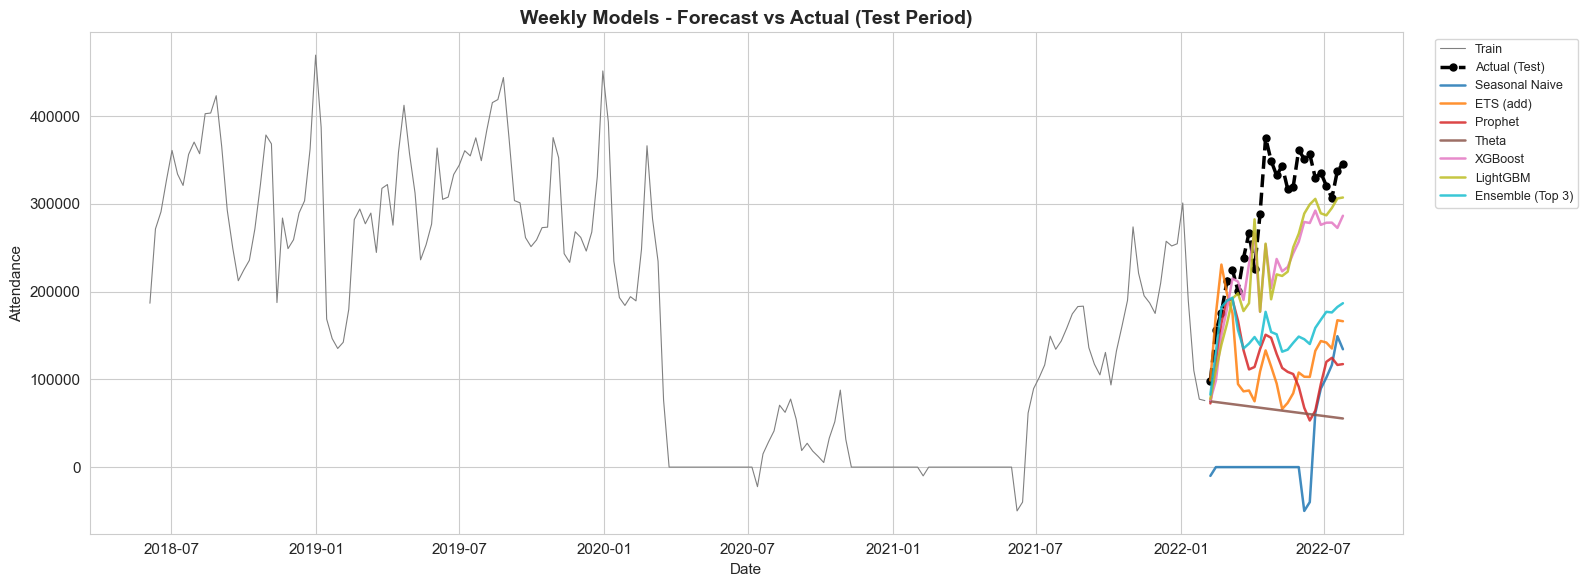

In [48]:
# ===== WEEKLY ENSEMBLE (Inverse-MAPE Weighted Top 3) =====

weekly_results_df = pd.DataFrame(weekly_results).sort_values('MAPE').reset_index(drop=True)

# Get top 3 models with full-length predictions
top3_names_w = []
for _, row in weekly_results_df.iterrows():
    name = row['Model']
    if name in weekly_preds and len(weekly_preds[name]) == WEEKLY_TEST_SIZE:
        top3_names_w.append(name)
    if len(top3_names_w) == 3:
        break

print(f"Top 3 models for ensemble: {top3_names_w}")

# Inverse-MAPE weights
weights_w = {}
for name in top3_names_w:
    mape = weekly_results_df[weekly_results_df['Model'] == name]['MAPE'].values[0]
    weights_w[name] = 1.0 / (mape + 1e-10)
total_w = sum(weights_w.values())
weights_w = {k: v / total_w for k, v in weights_w.items()}

print("Ensemble weights:")
for name, w in weights_w.items():
    print(f"  {name}: {w:.3f}")

# Weighted ensemble
ensemble_pred_w = np.zeros(WEEKLY_TEST_SIZE)
for name, w in weights_w.items():
    ensemble_pred_w += w * np.array(weekly_preds[name])[:WEEKLY_TEST_SIZE]

weekly_preds['Ensemble (Top 3)'] = ensemble_pred_w
ens_lower_w = np.zeros(WEEKLY_TEST_SIZE)
ens_upper_w = np.zeros(WEEKLY_TEST_SIZE)
for name, w in weights_w.items():
    if name in weekly_intervals:
        ens_lower_w += w * np.array(weekly_intervals[name][0])[:WEEKLY_TEST_SIZE]
        ens_upper_w += w * np.array(weekly_intervals[name][1])[:WEEKLY_TEST_SIZE]
weekly_intervals['Ensemble (Top 3)'] = (np.maximum(ens_lower_w, 0), ens_upper_w)
r = evaluate(weekly_test['attendance'], ensemble_pred_w, 'Ensemble (Top 3)')
weekly_results.append(r)
print(f"\n8. Ensemble (Top3) -> MAPE: {r['MAPE']:.2%}")

# ===== WEEKLY RESULTS SUMMARY =====
weekly_results_df = pd.DataFrame(weekly_results).sort_values('MAPE').reset_index(drop=True)
print("\n" + "=" * 60)
print("WEEKLY MODEL RESULTS (sorted by MAPE)")
print("=" * 60)
display(weekly_results_df)

# Visualization
plot_forecast(weekly_train, weekly_test, weekly_preds,
              'Weekly Models - Forecast vs Actual (Test Period)')

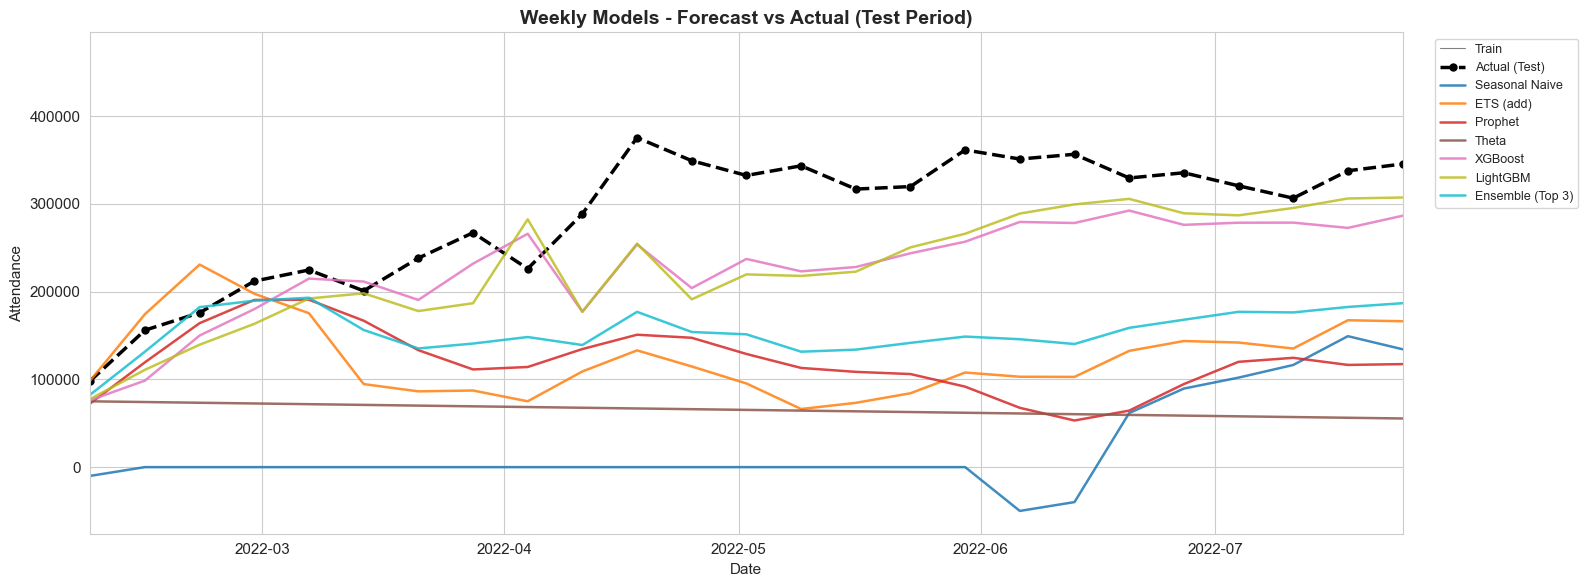

In [58]:
def plot_forecast(train_data, test_data, predictions_dict, title, focus_test=False):
    """Plot train, test, and multiple model predictions."""
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(train_data.index, train_data['attendance'], label='Train', color='gray', linewidth=0.8)
    ax.plot(test_data.index, test_data['attendance'], label='Actual (Test)', color='black',
            linewidth=2.5, linestyle='--', marker='o', markersize=5)

    colors = plt.cm.tab10(np.linspace(0, 1, len(predictions_dict)))
    for (name, preds), color in zip(predictions_dict.items(), colors):
        preds_arr = np.array(preds).flatten()[:len(test_data)]
        ax.plot(test_data.index[:len(preds_arr)], preds_arr, label=name, alpha=0.85, linewidth=1.8, color=color)

    if focus_test:
        ax.set_xlim(test_data.index.min(), test_data.index.max())

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Attendance')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()


plot_forecast(
    weekly_train,
    weekly_test,
    weekly_preds,
    'Weekly Models - Forecast vs Actual (Test Period)',
    focus_test=True
)

In [ ]:
# ============================================================
# XGBoost Weekly — Optimised Interval Coverage Analysis
# ============================================================
# Strategies:
#   A. Bias correction  (shift predictions by median training residual)
#   B. Fixed band on bias-corrected predictions (configurable)
#   C. Quantile regression  (adaptive-width intervals)
#   D. Minimum band lookup  (smallest band for each coverage target)
# ============================================================

from xgboost import XGBRegressor as _XGBReg

# ── Configurable parameters ──────────────────────────────────
INTERVAL_BAND = 8_000          # total fixed band width
HALF_BAND     = INTERVAL_BAND / 2
QUANTILE_LO   = 0.10           # lower quantile for quantile regression
QUANTILE_HI   = 0.90           # upper quantile for quantile regression

# ── Prepare data (exclude last data point) ───────────────────
n_pts            = len(xgb_pred_w) - 1
y_actual_w       = np.array(y_test_w).flatten()[:n_pts]
test_dates_w     = ml_test_w.index[:n_pts]
xgb_pred_trimmed = xgb_pred_w[:n_pts]

# =============================================================
# A.  BIAS CORRECTION  (median of training residuals)
# =============================================================
train_preds     = xgb_w.predict(X_train_w)
train_residuals = y_train_w.values - train_preds
bias_median     = np.median(train_residuals)
bias_mean       = np.mean(train_residuals)

corrected_pred = np.maximum(xgb_pred_trimmed + bias_median, 0)

print("=" * 80)
print("  A. BIAS CORRECTION — Training residual statistics")
print("=" * 80)
print(f"     Mean residual   : {bias_mean:+,.0f}")
print(f"     Median residual : {bias_median:+,.0f}")
print(f"     Std residual    : {np.std(train_residuals):,.0f}")
print(f"     → Predictions shifted by median ({bias_median:+,.0f})")
print()

# =============================================================
# B.  FIXED BAND  — raw vs bias-corrected comparison
# =============================================================
# Raw (no correction)
raw_lower = xgb_pred_trimmed - HALF_BAND
raw_upper = xgb_pred_trimmed + HALF_BAND
within_raw = (y_actual_w >= raw_lower) & (y_actual_w <= raw_upper)

# Bias-corrected
bc_lower = corrected_pred - HALF_BAND
bc_upper = corrected_pred + HALF_BAND
within_bc = (y_actual_w >= bc_lower) & (y_actual_w <= bc_upper)

cov_raw = within_raw.sum() / n_pts
cov_bc  = within_bc.sum() / n_pts

print("=" * 80)
print(f"  B. FIXED ±{HALF_BAND:,.0f} BAND — Raw vs Bias-corrected")
print("=" * 80)
print(f"     Raw XGBoost            : {within_raw.sum():>2}/{n_pts} = {cov_raw:>6.1%}")
print(f"     Bias-corrected XGBoost : {within_bc.sum():>2}/{n_pts} = {cov_bc:>6.1%}")
print()

# =============================================================
# C.  QUANTILE REGRESSION  (adaptive-width intervals)
# =============================================================
xgb_q_lo = _XGBReg(
    objective='reg:quantileerror', quantile_alpha=QUANTILE_LO,
    n_estimators=300, max_depth=4, learning_rate=0.05,
    min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0)

xgb_q_hi = _XGBReg(
    objective='reg:quantileerror', quantile_alpha=QUANTILE_HI,
    n_estimators=300, max_depth=4, learning_rate=0.05,
    min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0)

xgb_q_lo.fit(X_train_w, y_train_w)
xgb_q_hi.fit(X_train_w, y_train_w)

q_lower = np.maximum(xgb_q_lo.predict(X_test_w), 0)[:n_pts]
q_upper = xgb_q_hi.predict(X_test_w)[:n_pts]

within_q    = (y_actual_w >= q_lower) & (y_actual_w <= q_upper)
cov_q       = within_q.sum() / n_pts
q_widths    = q_upper - q_lower
avg_q_width = np.mean(q_widths)

print("=" * 80)
print(f"  C. QUANTILE REGRESSION ({QUANTILE_LO:.0%}–{QUANTILE_HI:.0%})")
print("=" * 80)
print(f"     Coverage        : {within_q.sum():>2}/{n_pts} = {cov_q:>6.1%}")
print(f"     Avg width       : {avg_q_width:>,.0f}")
print(f"     Min width       : {np.min(q_widths):>,.0f}")
print(f"     Max width       : {np.max(q_widths):>,.0f}")
print()

# =============================================================
# D.  MINIMUM BAND for target coverage (bias-corrected)
# =============================================================
abs_resid_bc = np.sort(np.abs(y_actual_w - corrected_pred))

print("=" * 80)
print("  D. MINIMUM HALF-BAND for target coverage (bias-corrected)")
print("=" * 80)
print(f"     {'Target':>8}  {'Points':>8}  {'Half-Band':>12}  {'Total Band':>12}")
print(f"     {'-' * 50}")
for target in [0.20, 0.40, 0.50, 0.60, 0.80, 1.00]:
    idx = min(int(np.ceil(target * n_pts)) - 1, n_pts - 1)
    hb  = abs_resid_bc[idx]
    pts = idx + 1
    print(f"     {target:>7.0%}  {pts:>5}/{n_pts:<3}  {hb:>12,.0f}  {2*hb:>12,.0f}")
print()

# =============================================================
#  SUMMARY TABLE
# =============================================================
print("=" * 80)
print("  SUMMARY — Coverage & Average Interval Width")
print("=" * 80)
rows = [
    ("Raw XGBoost ± fixed band",       within_raw, float(INTERVAL_BAND)),
    ("Bias-corrected ± fixed band",    within_bc,  float(INTERVAL_BAND)),
    (f"Quantile regression ({QUANTILE_LO:.0%}–{QUANTILE_HI:.0%})", within_q, avg_q_width),
]
print(f"  {'Method':<40s}  {'Coverage':>14}  {'Avg Width':>12}")
print(f"  {'-' * 70}")
for name, mask, w in rows:
    cov = mask.sum() / n_pts
    print(f"  {name:<40s}  {mask.sum():>2}/{n_pts} = {cov:>5.1%}  {w:>12,.0f}")
print("=" * 80)

# =============================================================
#  PER-WEEK DETAILED BREAKDOWN  (bias-corrected + quantile)
# =============================================================
print(f"\n{'Week':<12} {'Actual':>9} {'RawPred':>9} {'BCPred':>9} "
      f"{'BC±Band?':>9} {'QLo':>9} {'QHi':>9} {'QR?':>5}")
print("-" * 82)
for i in range(n_pts):
    d     = str(test_dates_w[i].date())
    bc_ok = "YES" if within_bc[i] else "NO"
    q_ok  = "YES" if within_q[i]  else "NO"
    print(f"{d:<12} {y_actual_w[i]:>9,.0f} {xgb_pred_trimmed[i]:>9,.0f} "
          f"{corrected_pred[i]:>9,.0f} {bc_ok:>7}   "
          f"{q_lower[i]:>9,.0f} {q_upper[i]:>9,.0f} {q_ok:>5}")

# =============================================================
#  VISUALISATION  — 3 panels
# =============================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharex=True)

# --- Panel 1: Raw predictions + fixed band ---
ax = axes[0]
ax.plot(test_dates_w, y_actual_w, 'k--o', lw=2, ms=5, label='Actual', zorder=5)
ax.plot(test_dates_w, xgb_pred_trimmed, 's-', color='tab:blue', lw=1.5, ms=4,
        label='Raw XGBoost', zorder=4)
ax.fill_between(test_dates_w, raw_lower, raw_upper, alpha=0.20, color='tab:blue',
                label=f'±{HALF_BAND:,.0f} band')
out = ~within_raw
if out.any():
    ax.scatter(test_dates_w[out], y_actual_w[out], c='red', s=90, zorder=6,
               edgecolors='darkred', lw=1.2, label='Outside')
ax.set_title(f'Raw XGBoost ± {HALF_BAND:,.0f}  —  '
             f'Coverage {within_raw.sum()}/{n_pts} = {cov_raw:.1%}',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Attendance')
ax.legend(loc='upper left', fontsize=9)

# --- Panel 2: Bias-corrected + fixed band ---
ax = axes[1]
ax.plot(test_dates_w, y_actual_w, 'k--o', lw=2, ms=5, label='Actual', zorder=5)
ax.plot(test_dates_w, corrected_pred, 's-', color='tab:orange', lw=1.5, ms=4,
        label=f'Bias-corrected (shift {bias_median:+,.0f})', zorder=4)
ax.fill_between(test_dates_w, bc_lower, bc_upper, alpha=0.20, color='tab:orange',
                label=f'±{HALF_BAND:,.0f} band')
out = ~within_bc
if out.any():
    ax.scatter(test_dates_w[out], y_actual_w[out], c='red', s=90, zorder=6,
               edgecolors='darkred', lw=1.2, label='Outside')
ax.set_title(f'Bias-corrected ± {HALF_BAND:,.0f}  —  '
             f'Coverage {within_bc.sum()}/{n_pts} = {cov_bc:.1%}',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Attendance')
ax.legend(loc='upper left', fontsize=9)

# --- Panel 3: Quantile regression (adaptive) ---
ax = axes[2]
ax.plot(test_dates_w, y_actual_w, 'k--o', lw=2, ms=5, label='Actual', zorder=5)
ax.plot(test_dates_w, (q_lower + q_upper) / 2, 's-', color='tab:green', lw=1.5, ms=4,
        label='QR midpoint', zorder=4)
ax.fill_between(test_dates_w, q_lower, q_upper, alpha=0.20, color='tab:green',
                label=f'Quantile {QUANTILE_LO:.0%}–{QUANTILE_HI:.0%}')
out = ~within_q
if out.any():
    ax.scatter(test_dates_w[out], y_actual_w[out], c='red', s=90, zorder=6,
               edgecolors='darkred', lw=1.2, label='Outside')
ax.set_title(f'Quantile Regression ({QUANTILE_LO:.0%}–{QUANTILE_HI:.0%})  —  '
             f'Coverage {within_q.sum()}/{n_pts} = {cov_q:.1%}  |  '
             f'Avg width {avg_q_width:,.0f}',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Attendance')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=9)

for a in axes:
    a.tick_params(axis='x', rotation=45)

plt.suptitle('XGBoost Weekly — Interval Optimisation Comparison\n(last week excluded)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# LightGBM Weekly — Optimised Interval Coverage Analysis
# ============================================================
# Strategies:
#   A. Bias correction  (shift predictions by median training residual)
#   B. Fixed band on bias-corrected predictions (configurable)
#   C. Quantile regression  (adaptive-width intervals)
#   D. Minimum band lookup  (smallest band for each coverage target)
# ============================================================

from lightgbm import LGBMRegressor as _LGBMReg

# ── Configurable parameters ──────────────────────────────────
INTERVAL_BAND_LGB = 80_000        # total fixed band width (adjust as needed)
HALF_BAND_LGB     = INTERVAL_BAND_LGB / 2
QUANTILE_LO_LGB   = 0.10          # lower quantile for quantile regression
QUANTILE_HI_LGB   = 0.90          # upper quantile for quantile regression

# ── Prepare data (exclude last data point) ───────────────────
n_pts_l            = len(lgb_pred_w) - 1
y_actual_l         = np.array(y_test_w).flatten()[:n_pts_l]
test_dates_l       = ml_test_w.index[:n_pts_l]
lgb_pred_trimmed   = lgb_pred_w[:n_pts_l]

# =============================================================
# A.  BIAS CORRECTION  (median of training residuals)
# =============================================================
lgb_train_preds     = lgb_w.predict(X_train_w)
lgb_train_residuals = y_train_w.values - lgb_train_preds
lgb_bias_median     = np.median(lgb_train_residuals)
lgb_bias_mean       = np.mean(lgb_train_residuals)

lgb_corrected_pred = np.maximum(lgb_pred_trimmed + lgb_bias_median, 0)

print("=" * 80)
print("  A. BIAS CORRECTION — LightGBM Training residual statistics")
print("=" * 80)
print(f"     Mean residual   : {lgb_bias_mean:+,.0f}")
print(f"     Median residual : {lgb_bias_median:+,.0f}")
print(f"     Std residual    : {np.std(lgb_train_residuals):,.0f}")
print(f"     → Predictions shifted by median ({lgb_bias_median:+,.0f})")
print()

# =============================================================
# B.  FIXED BAND  — raw vs bias-corrected comparison
# =============================================================
# Raw (no correction)
lgb_raw_lower = lgb_pred_trimmed - HALF_BAND_LGB
lgb_raw_upper = lgb_pred_trimmed + HALF_BAND_LGB
lgb_within_raw = (y_actual_l >= lgb_raw_lower) & (y_actual_l <= lgb_raw_upper)

# Bias-corrected
lgb_bc_lower = lgb_corrected_pred - HALF_BAND_LGB
lgb_bc_upper = lgb_corrected_pred + HALF_BAND_LGB
lgb_within_bc = (y_actual_l >= lgb_bc_lower) & (y_actual_l <= lgb_bc_upper)

lgb_cov_raw = lgb_within_raw.sum() / n_pts_l
lgb_cov_bc  = lgb_within_bc.sum() / n_pts_l

print("=" * 80)
print(f"  B. FIXED ±{HALF_BAND_LGB:,.0f} BAND — Raw vs Bias-corrected")
print("=" * 80)
print(f"     Raw LightGBM            : {lgb_within_raw.sum():>2}/{n_pts_l} = {lgb_cov_raw:>6.1%}")
print(f"     Bias-corrected LightGBM : {lgb_within_bc.sum():>2}/{n_pts_l} = {lgb_cov_bc:>6.1%}")
print()

# =============================================================
# C.  QUANTILE REGRESSION  (adaptive-width intervals)
# =============================================================
lgb_q_lo = _LGBMReg(
    objective='quantile', alpha=QUANTILE_LO_LGB,
    n_estimators=300, max_depth=4, learning_rate=0.05,
    min_child_samples=5, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1)

lgb_q_hi = _LGBMReg(
    objective='quantile', alpha=QUANTILE_HI_LGB,
    n_estimators=300, max_depth=4, learning_rate=0.05,
    min_child_samples=5, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1)

lgb_q_lo.fit(X_train_w, y_train_w)
lgb_q_hi.fit(X_train_w, y_train_w)

lgb_ql = np.maximum(lgb_q_lo.predict(X_test_w), 0)[:n_pts_l]
lgb_qh = lgb_q_hi.predict(X_test_w)[:n_pts_l]

lgb_within_q    = (y_actual_l >= lgb_ql) & (y_actual_l <= lgb_qh)
lgb_cov_q       = lgb_within_q.sum() / n_pts_l
lgb_q_widths    = lgb_qh - lgb_ql
lgb_avg_q_width = np.mean(lgb_q_widths)

print("=" * 80)
print(f"  C. QUANTILE REGRESSION ({QUANTILE_LO_LGB:.0%}–{QUANTILE_HI_LGB:.0%})")
print("=" * 80)
print(f"     Coverage        : {lgb_within_q.sum():>2}/{n_pts_l} = {lgb_cov_q:>6.1%}")
print(f"     Avg width       : {lgb_avg_q_width:>,.0f}")
print(f"     Min width       : {np.min(lgb_q_widths):>,.0f}")
print(f"     Max width       : {np.max(lgb_q_widths):>,.0f}")
print()

# =============================================================
# D.  MINIMUM BAND for target coverage (bias-corrected)
# =============================================================
lgb_abs_resid_bc = np.sort(np.abs(y_actual_l - lgb_corrected_pred))

print("=" * 80)
print("  D. MINIMUM HALF-BAND for target coverage (bias-corrected)")
print("=" * 80)
print(f"     {'Target':>8}  {'Points':>8}  {'Half-Band':>12}  {'Total Band':>12}")
print(f"     {'-' * 50}")
for target in [0.20, 0.40, 0.50, 0.60, 0.80, 1.00]:
    idx = min(int(np.ceil(target * n_pts_l)) - 1, n_pts_l - 1)
    hb  = lgb_abs_resid_bc[idx]
    pts = idx + 1
    print(f"     {target:>7.0%}  {pts:>5}/{n_pts_l:<3}  {hb:>12,.0f}  {2*hb:>12,.0f}")
print()

# =============================================================
#  SUMMARY TABLE
# =============================================================
print("=" * 80)
print("  SUMMARY — LightGBM Coverage & Average Interval Width")
print("=" * 80)
lgb_rows = [
    ("Raw LightGBM ± fixed band",       lgb_within_raw, float(INTERVAL_BAND_LGB)),
    ("Bias-corrected ± fixed band",     lgb_within_bc,  float(INTERVAL_BAND_LGB)),
    (f"Quantile regression ({QUANTILE_LO_LGB:.0%}–{QUANTILE_HI_LGB:.0%})", lgb_within_q, lgb_avg_q_width),
]
print(f"  {'Method':<40s}  {'Coverage':>14}  {'Avg Width':>12}")
print(f"  {'-' * 70}")
for name, mask, w in lgb_rows:
    cov = mask.sum() / n_pts_l
    print(f"  {name:<40s}  {mask.sum():>2}/{n_pts_l} = {cov:>5.1%}  {w:>12,.0f}")
print("=" * 80)

# =============================================================
#  PER-WEEK DETAILED BREAKDOWN  (bias-corrected + quantile)
# =============================================================
print(f"\n{'Week':<12} {'Actual':>9} {'RawPred':>9} {'BCPred':>9} "
      f"{'BC±Band?':>9} {'QLo':>9} {'QHi':>9} {'QR?':>5}")
print("-" * 82)
for i in range(n_pts_l):
    d      = str(test_dates_l[i].date())
    bc_ok  = "YES" if lgb_within_bc[i] else "NO"
    q_ok   = "YES" if lgb_within_q[i]  else "NO"
    print(f"{d:<12} {y_actual_l[i]:>9,.0f} {lgb_pred_trimmed[i]:>9,.0f} "
          f"{lgb_corrected_pred[i]:>9,.0f} {bc_ok:>7}   "
          f"{lgb_ql[i]:>9,.0f} {lgb_qh[i]:>9,.0f} {q_ok:>5}")

# =============================================================
#  VISUALISATION  — 3 panels
# =============================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharex=True)

# --- Panel 1: Raw predictions + fixed band ---
ax = axes[0]
ax.plot(test_dates_l, y_actual_l, 'k--o', lw=2, ms=5, label='Actual', zorder=5)
ax.plot(test_dates_l, lgb_pred_trimmed, 's-', color='tab:green', lw=1.5, ms=4,
        label='Raw LightGBM', zorder=4)
ax.fill_between(test_dates_l, lgb_raw_lower, lgb_raw_upper, alpha=0.20,
                color='tab:green', label=f'±{HALF_BAND_LGB:,.0f} band')
out = ~lgb_within_raw
if out.any():
    ax.scatter(test_dates_l[out], y_actual_l[out], c='red', s=90, zorder=6,
               edgecolors='darkred', lw=1.2, label='Outside')
ax.set_title(f'Raw LightGBM ± {HALF_BAND_LGB:,.0f}  —  '
             f'Coverage {lgb_within_raw.sum()}/{n_pts_l} = {lgb_cov_raw:.1%}',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Attendance')
ax.legend(loc='upper left', fontsize=9)

# --- Panel 2: Bias-corrected + fixed band ---
ax = axes[1]
ax.plot(test_dates_l, y_actual_l, 'k--o', lw=2, ms=5, label='Actual', zorder=5)
ax.plot(test_dates_l, lgb_corrected_pred, 's-', color='tab:orange', lw=1.5, ms=4,
        label=f'Bias-corrected (shift {lgb_bias_median:+,.0f})', zorder=4)
ax.fill_between(test_dates_l, lgb_bc_lower, lgb_bc_upper, alpha=0.20,
                color='tab:orange', label=f'±{HALF_BAND_LGB:,.0f} band')
out = ~lgb_within_bc
if out.any():
    ax.scatter(test_dates_l[out], y_actual_l[out], c='red', s=90, zorder=6,
               edgecolors='darkred', lw=1.2, label='Outside')
ax.set_title(f'Bias-corrected ± {HALF_BAND_LGB:,.0f}  —  '
             f'Coverage {lgb_within_bc.sum()}/{n_pts_l} = {lgb_cov_bc:.1%}',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Attendance')
ax.legend(loc='upper left', fontsize=9)

# --- Panel 3: Quantile regression (adaptive) ---
ax = axes[2]
ax.plot(test_dates_l, y_actual_l, 'k--o', lw=2, ms=5, label='Actual', zorder=5)
ax.plot(test_dates_l, (lgb_ql + lgb_qh) / 2, 's-', color='tab:purple', lw=1.5, ms=4,
        label='QR midpoint', zorder=4)
ax.fill_between(test_dates_l, lgb_ql, lgb_qh, alpha=0.20, color='tab:purple',
                label=f'Quantile {QUANTILE_LO_LGB:.0%}–{QUANTILE_HI_LGB:.0%}')
out = ~lgb_within_q
if out.any():
    ax.scatter(test_dates_l[out], y_actual_l[out], c='red', s=90, zorder=6,
               edgecolors='darkred', lw=1.2, label='Outside')
ax.set_title(f'Quantile Regression ({QUANTILE_LO_LGB:.0%}–{QUANTILE_HI_LGB:.0%})  —  '
             f'Coverage {lgb_within_q.sum()}/{n_pts_l} = {lgb_cov_q:.1%}  |  '
             f'Avg width {lgb_avg_q_width:,.0f}',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Attendance')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=9)

for a in axes:
    a.tick_params(axis='x', rotation=45)

plt.suptitle('LightGBM Weekly — Interval Optimisation Comparison\n(last week excluded)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
